<a href="https://colab.research.google.com/github/07hinata/RNN/blob/main/modelyF_%3EInvalid_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install neuralforecast

print("✓")

✓


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoGRU, AutoLSTM

import warnings
warnings.filterwarnings('ignore')

horizon = 1096
window_size = 60

df = pd.read_csv('dly-0-203-0-11651-T.csv', names=['ID', 'STANICE', 'TYP', 'DT', 'VALUE', 'X', 'Y', 'Z'], skiprows=1)
df['DT'] = pd.to_datetime(df['DT'])
df = df[(df['TYP'] == 'AVG') & (df['DT'].between('2010-01-01', '2025-12-31'))].copy()
df = df.sort_values('DT').reset_index(drop=True)

final_results = []

print("✓")

✓


In [3]:
df_nixtla = df[['DT', 'VALUE']].copy()
df_nixtla.columns = ['ds', 'y']
df_nixtla['unique_id'] = 'Svobodne_Dvory'

train_nixtla = df_nixtla[:-horizon]
test_nixtla = df_nixtla[-horizon:]

my_config = {
    "early_stop_patience_steps": 5,
    "max_steps": 100,
    "val_check_steps": 1
}

models_nixtla = [
    AutoGRU(h=horizon, config=my_config, num_samples=5),
    AutoLSTM(h=horizon, config=my_config, num_samples=5)
]

nf = NeuralForecast(models=models_nixtla, freq='D')
nf.fit(df=train_nixtla, val_size=horizon)
forecasts_neural = nf.predict()
forecasts_neural = forecasts_neural.merge(test_nixtla[['ds', 'y']], on='ds')

for mod in ['AutoGRU', 'AutoLSTM']:
    y_true = forecasts_neural['y']
    y_pred = forecasts_neural[mod]

    final_results.append({
        'Model': f'Nixtla-{mod}',
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'Predictions': y_pred.values
    })

print("✓")

2026-04-10 12:10:43,755	INFO worker.py:2013 -- Started a local Ray instance.
2026-04-10 12:10:46,655	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.


+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-04-10_12-10-31   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 5                                 |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-04-10_12-10-31
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-10_12-10-31_380333_3796/artifacts/2026-04-10_12-10-46/_train_tune_2026-04-10_12-10-31/driver_artifacts`


(_train_tune pid=4484) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=4484) /usr/local/lib/python3.12/dist-packages/neuralforecast/common/_base_model.py:152: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 3288
(_train_tune pid=4484)   warnings.warn(
(_train_tune pid=4484) Seed set to 1
(_train_tune pid=4484) GPU available: True (cuda), used: True
(_train_tune pid=4484) TPU available: False, using: 0 TPU cores
(_train_tune pid=4484) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=4484) `Trainer(val_check_interval=1)` was configured so validati

(_train_tune pid=4484) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=4484) ┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=4484) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=4484) │ 0 │ loss         │ MAE           │      0 │ train │     0 │
(_train_tune pid=4484) │ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
(_train_tune pid=4484) │ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
(_train_tune pid=4484) │ 3 │ hist_encoder │ GRU           │  363 K │ train │     0 │
(_train_tune pid=4484) │ 4 │ mlp_decoder  │ MLP           │ 25.9 K │ train │     0 │
(_train_tune pid=4484) └───┴──────────────┴───────────────┴────────┴───────┴───────┘
(_train_tune pid=4484) Trainable params: 388 K                                                         
(_train_tune pid=4484) Non-trainable params: 0                                                         
(_train_tune pid=4484) Tota

(_train_tune pid=4484) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(val_check_interval=1)` was configured so validation will run after every batch.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(val_check_interval=1)` was configured so validation will run after every batch.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

✓


In [4]:
data_b = df['VALUE'].values
train_b = data_b[:-horizon]
test_b = data_b[-horizon:]

scaler_b = MinMaxScaler(feature_range=(0, 1))
train_scaled_b = scaler_b.fit_transform(train_b.reshape(-1, 1))
test_scaled_b = scaler_b.transform(test_b.reshape(-1, 1))

def create_b_windows(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

test_combined_b = np.concatenate((train_scaled_b[-window_size:], test_scaled_b),
                                 axis=0)
X_train_b, y_train_b = create_b_windows(train_scaled_b, window_size)
X_test_b, y_test_b = create_b_windows(test_combined_b, window_size)

X_train_b = X_train_b.reshape(X_train_b.shape[0], X_train_b.shape[1], 1)
X_test_b = X_test_b.reshape(X_test_b.shape[0], X_test_b.shape[1], 1)

model_b = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, 1)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])

model_b.compile(optimizer='adam', loss='mse')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                              restore_best_weights=True)
history_b = model_b.fit(X_train_b, y_train_b, epochs=100, batch_size=32,
                        validation_split=0.1, shuffle=False,
                        callbacks=[early_stop], verbose=1)

preds_b = model_b.predict(X_test_b)
preds_b_celsius = scaler_b.inverse_transform(preds_b).flatten()
y_true_b = scaler_b.inverse_transform(y_test_b.reshape(-1, 1)).flatten()

final_results.append({
    'Model': 'TF-LSTM-Base',
    'RMSE': np.sqrt(mean_squared_error(y_true_b, preds_b_celsius)),
    'R2': r2_score(y_true_b, preds_b_celsius),
    'MAE': mean_absolute_error(y_true_b, preds_b_celsius),
    'Predictions': preds_b_celsius
})

print("✓")

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0408 - val_loss: 0.0063
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0071 - val_loss: 0.0055
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0070 - val_loss: 0.0051
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0065 - val_loss: 0.0049
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0061 - val_loss: 0.0047
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0058 - val_loss: 0.0045
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0044
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0053 - val_loss: 0.0042
Epoch 9/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0051 - val_loss: 0.0041
Epoch 10/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0049 - val_loss: 0.0040
Epoch 11/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0047 - val_loss: 0.0038
Epoch 12/100
132/132 ━━━━━━━━━━━━━━━━━━━

In [5]:
df['day_of_year'] = df['DT'].dt.dayofyear
df['sin_day'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_day'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['temp_roll_7'] = df['VALUE'].rolling(window=7).mean().fillna(method='bfill')
df['roll_diff'] = df['temp_roll_7'] - df['temp_roll_7'].shift(7).bfill()

features = ['VALUE', 'sin_day', 'cos_day', 'temp_roll_7', 'roll_diff']

data_c = df[features].values
train_c = data_c[:-horizon]
test_c = data_c[-horizon:]

scaler_c = MinMaxScaler(feature_range=(0, 1))
train_scaled_c = scaler_c.fit_transform(train_c)
test_scaled_c = scaler_c.transform(test_c)

def create_c_windows(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

test_combined_c = np.concatenate((train_scaled_c[-window_size:], test_scaled_c),
                                 axis=0)
X_train_c, y_train_c = create_c_windows(train_scaled_c, window_size)
X_test_c, y_test_c = create_c_windows(test_combined_c, window_size)

model_c = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, len(features))),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_c.compile(optimizer='adam', loss='mse')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_c = model_c.fit(X_train_c, y_train_c, epochs=100, batch_size=32, validation_split=0.1, shuffle=False, callbacks=[early_stop], verbose=1)

preds_c = model_c.predict(X_test_c)
simple_matrix = np.zeros((len(preds_c), len(features)))
simple_matrix[:, 0] = preds_c.flatten()
preds_c_celsius = scaler_c.inverse_transform(simple_matrix)[:, 0]
y_true_c = test_c[:, 0]

final_results.append({
    'Model': 'TF-LSTM-Complex',
    'RMSE': np.sqrt(mean_squared_error(y_true_c, preds_c_celsius)),
    'R2': r2_score(y_true_c, preds_c_celsius),
    'MAE': mean_absolute_error(y_true_c, preds_c_celsius),
    'Predictions': preds_c_celsius
})

print("✓")

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0458 - val_loss: 0.0061
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0112 - val_loss: 0.0053
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0100 - val_loss: 0.0051
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0094 - val_loss: 0.0057
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0092 - val_loss: 0.0048
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0088 - val_loss: 0.0061
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0082 - val_loss: 0.0048
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0081 - val_loss: 0.0053
Epoch 9/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0079 - val_loss: 0.0049
Epoch 10/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0075 - val_loss: 0.0054
Epoch 11/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0074 - val_loss: 0.0054
Epoch 12/100
132/132 ━━━━━━━━━


SROVNÁVACÍ TABULKA PRO BAKALÁŘSKOU PRÁCI
          Model     RMSE       R2      MAE
 Nixtla-AutoGRU 4.341231 0.695407 3.532604
Nixtla-AutoLSTM 4.490662 0.674077 3.647970
   TF-LSTM-Base 2.297377 0.914698 1.804546
TF-LSTM-Complex 3.425518 0.810353 2.735215


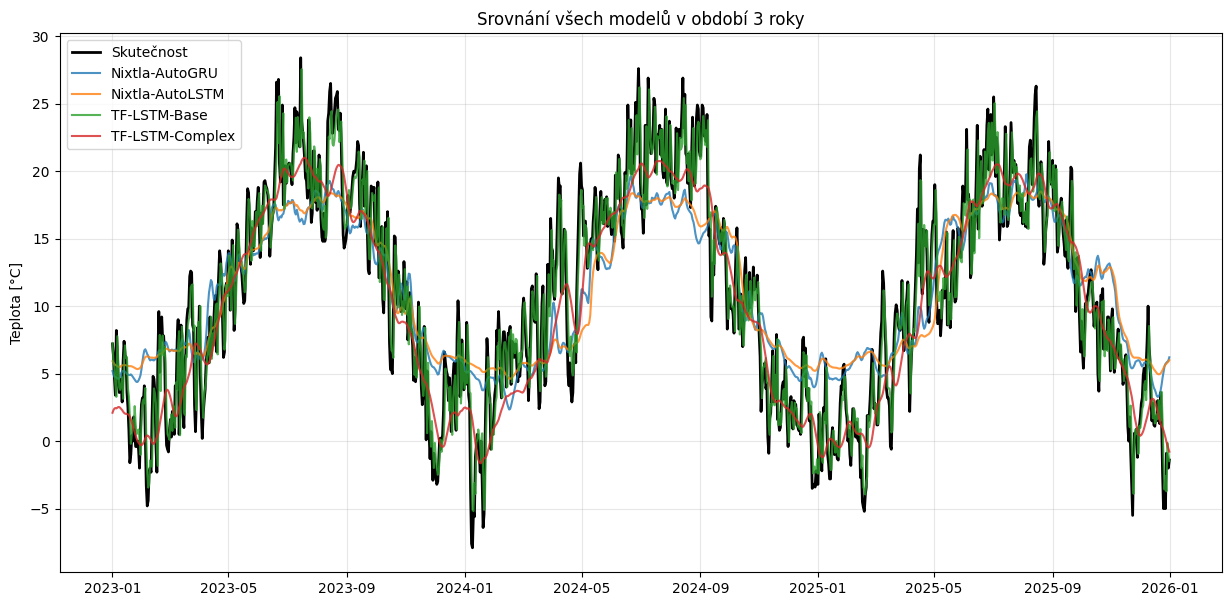

In [6]:
print("\n" + "="*50)
print("SROVNÁVACÍ TABULKA PRO BAKALÁŘSKOU PRÁCI")
print("="*50)

df_final = pd.DataFrame(final_results).drop(columns=['Predictions'])
print(df_final.to_string(index=False))

plt.figure(figsize=(15, 7))
test_dates = df['DT'][-horizon:].values

plt.plot(test_dates[-horizon:], y_true_b[-horizon:], label='Skutečnost', color='black', lw=2)
for res in final_results:
    plt.plot(test_dates[-horizon:], res['Predictions'][-horizon:], label=res['Model'], alpha=0.8)

plt.title("Srovnání všech modelů v období 3 roky")
plt.ylabel("Teplota [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

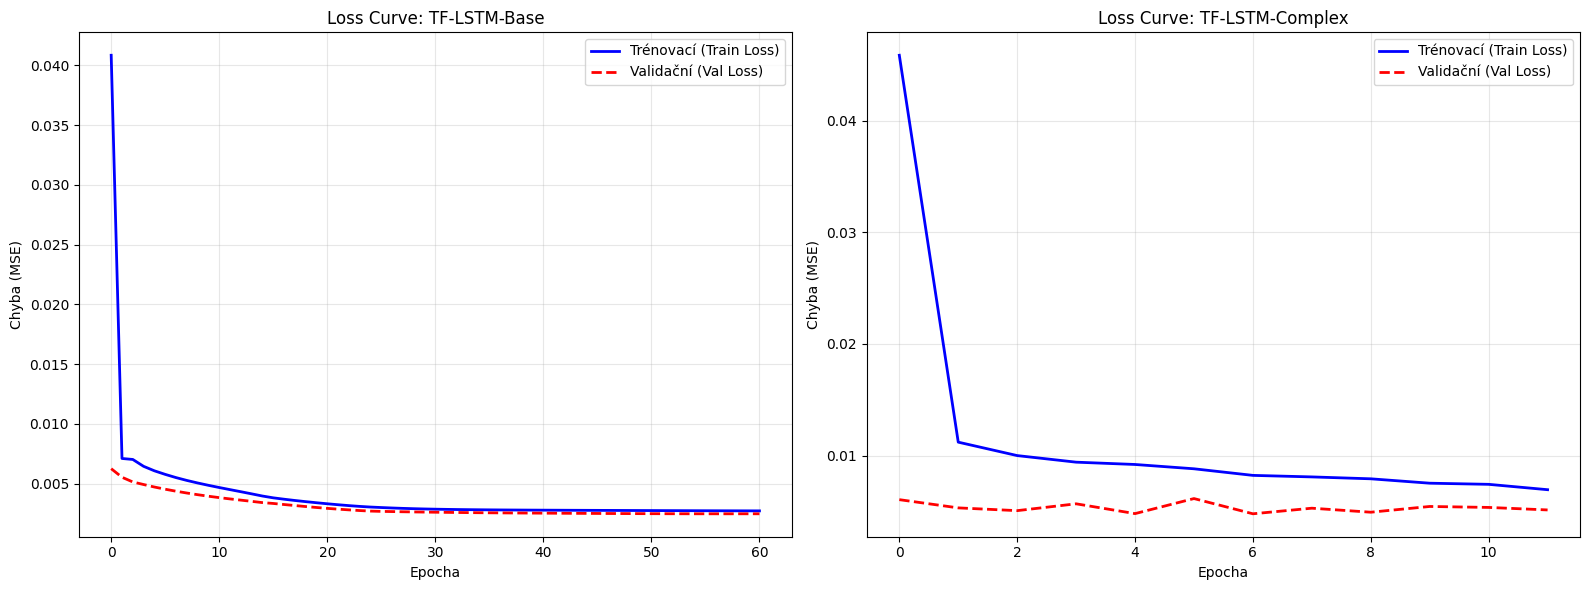

In [7]:
def plot_learning_curves(history, title):
    plt.plot(history.history['loss'], label='Trénovací (Train Loss)', color='blue', lw=2)
    plt.plot(history.history['val_loss'], label='Validační (Val Loss)', color='red', lw=2, linestyle='--')
    plt.title(title)
    plt.xlabel('Epocha')
    plt.ylabel('Chyba (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plot_learning_curves(history_b, "Loss Curve: TF-LSTM-Base")

plt.subplot(1, 2, 2)
plot_learning_curves(history_c, "Loss Curve: TF-LSTM-Complex")

plt.tight_layout()
plt.show()

In [8]:
results_gru = nf.models[0].results.get_dataframe()
results_lstm = nf.models[1].results.get_dataframe()

existing_cols = ['loss', 'train_loss', 'time_total_s', 'training_iteration']

print("Výsledky 5 pokusů AutoGRU:")
print(results_gru[existing_cols].sort_values('loss'))

print("\nVýsledky 5 pokusů AutoLSTM:")
print(results_lstm[existing_cols].sort_values('loss'))

Výsledky 5 pokusů AutoGRU:
       loss  train_loss  time_total_s  training_iteration
0  3.543794    0.513602     17.070524                  17
1  3.543794    0.513602     14.651688                  17
2  3.543794    0.513602     15.419417                  17
3  3.543794    0.513602     15.883586                  17
4  3.543794    0.513602     14.865222                  17

Výsledky 5 pokusů AutoLSTM:
       loss  train_loss  time_total_s  training_iteration
0  3.547831    0.510914     12.323622                  23
1  3.547831    0.510914     12.375461                  23
2  3.547831    0.510914     12.378953                  23
3  3.547831    0.510914     12.362991                  23
4  3.547831    0.510914     12.519870                  23


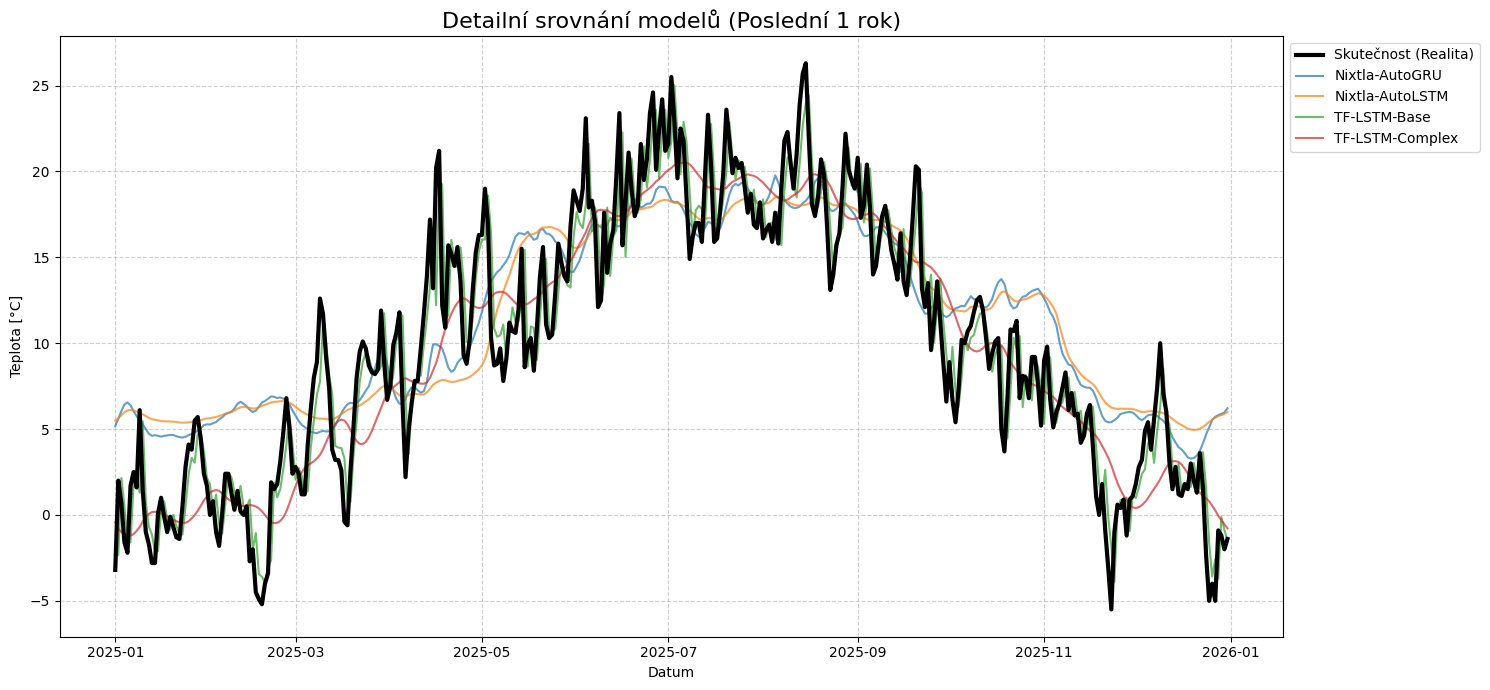

In [9]:
plt.figure(figsize=(15, 7))
last_year = 365

plt.plot(test_nixtla['ds'][-last_year:], test_nixtla['y'][-last_year:],
         label='Skutečnost (Realita)', color='black', lw=3, zorder=5)

for res in final_results:
    plt.plot(test_nixtla['ds'][-last_year:], res['Predictions'][-last_year:],
             label=res['Model'], alpha=0.7)

plt.title("Detailní srovnání modelů (Poslední 1 rok)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Teplota [°C]")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

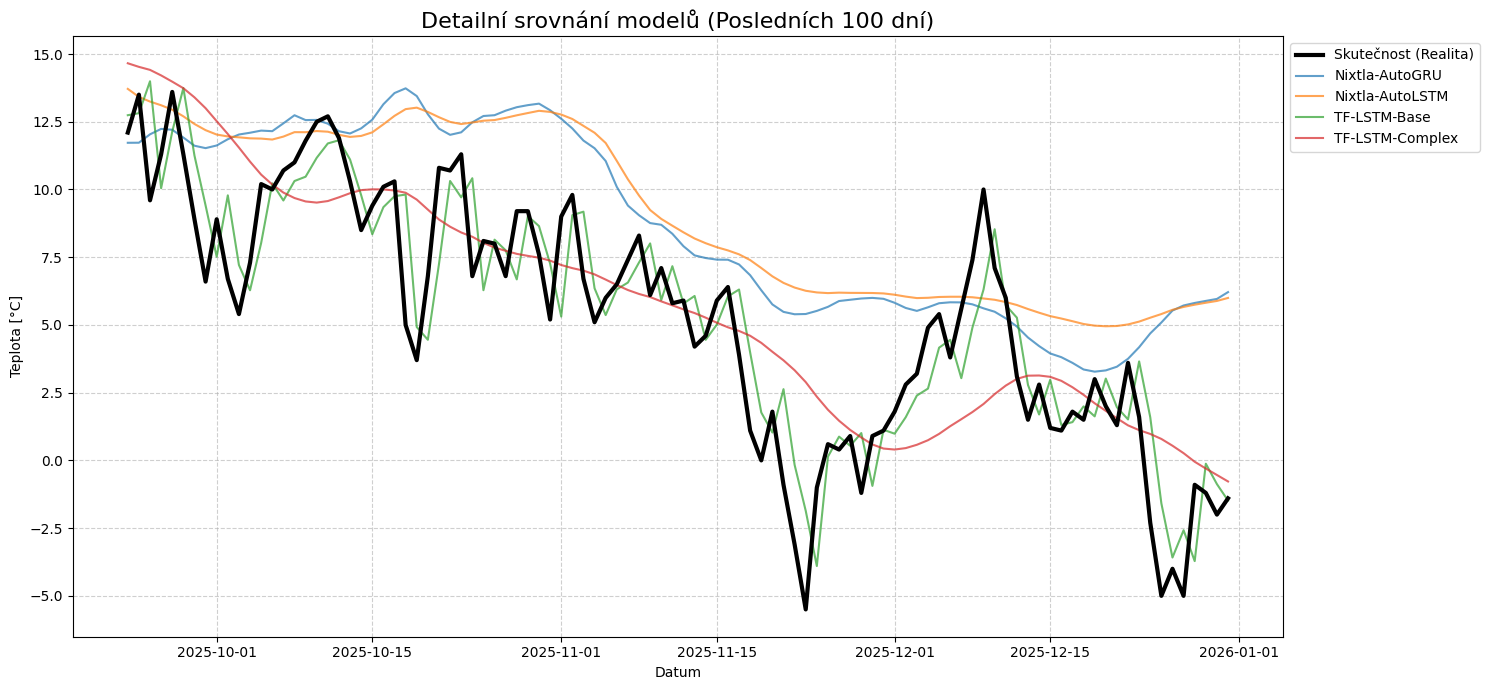

In [10]:
plt.figure(figsize=(15, 7))
last_days = 100

plt.plot(test_nixtla['ds'][-last_days:], test_nixtla['y'][-last_days:],
         label='Skutečnost (Realita)', color='black', lw=3, zorder=5)

for res in final_results:
    plt.plot(test_nixtla['ds'][-last_days:], res['Predictions'][-last_days:],
             label=res['Model'], alpha=0.7)

plt.title("Detailní srovnání modelů (Posledních 100 dní)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Teplota [°C]")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

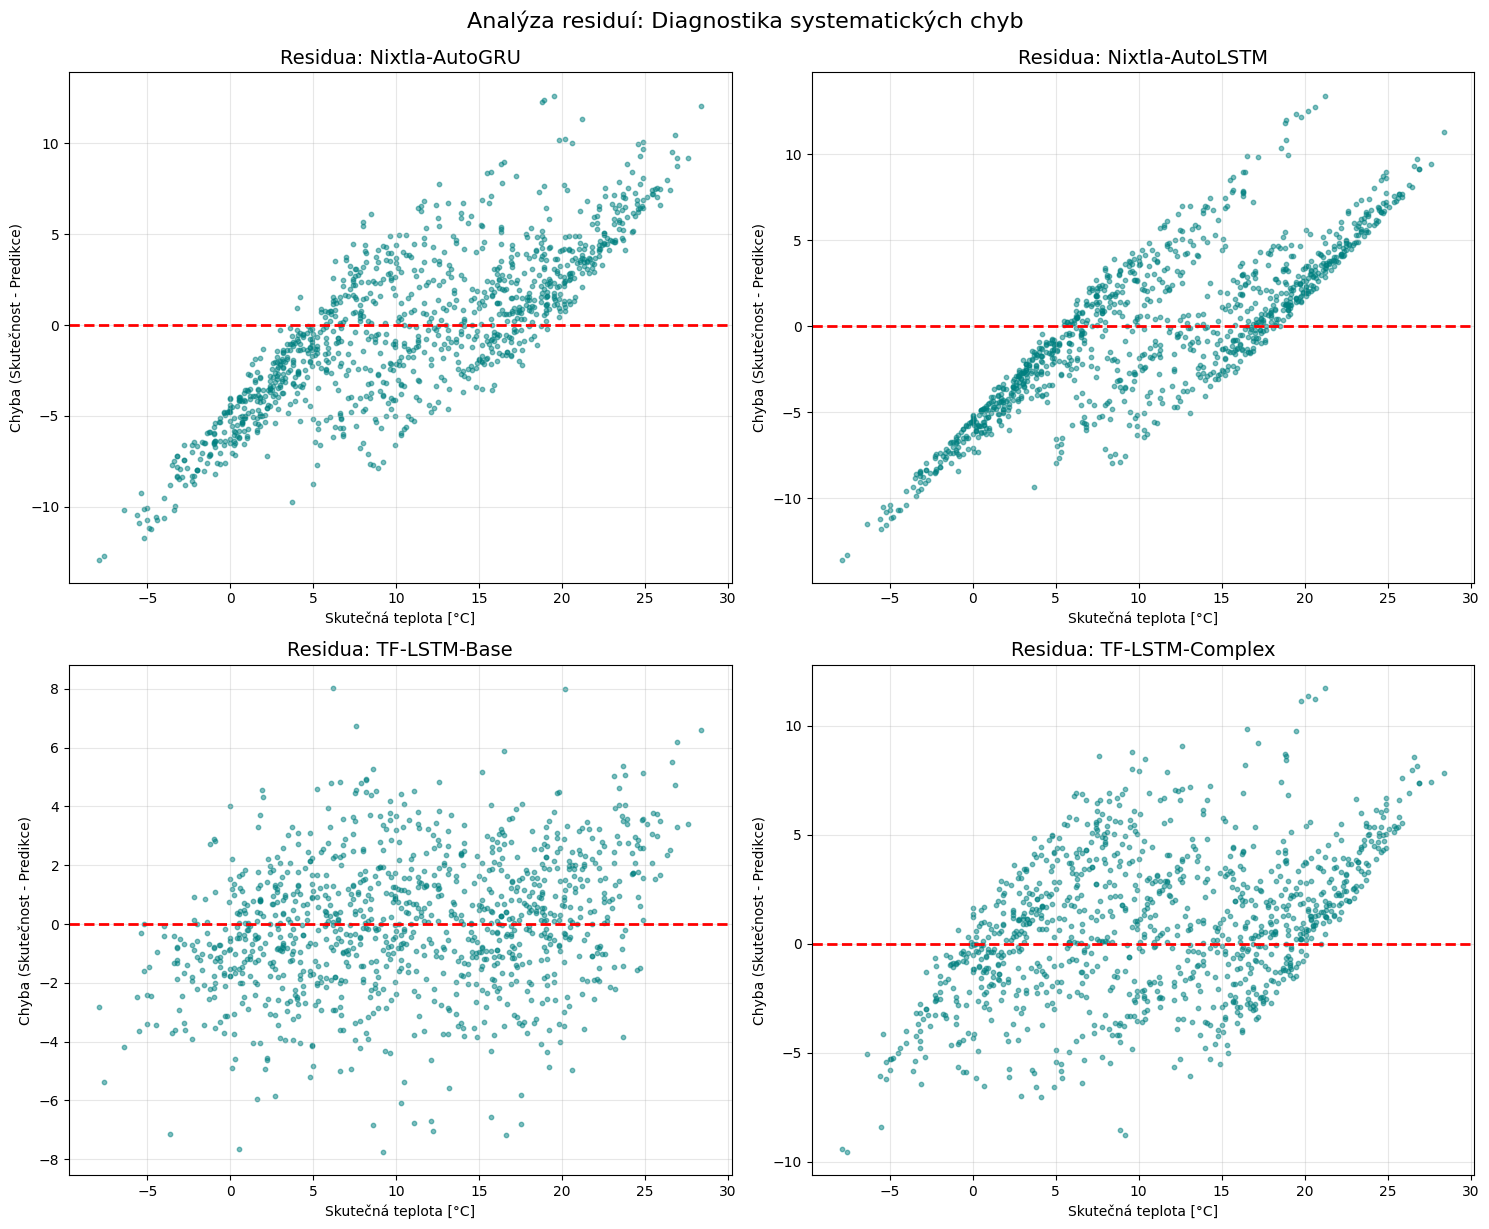

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, res in enumerate(final_results):
    if 'Nixtla' in res['Model']:
        y_actual = forecasts_neural['y'].values
    elif 'Base' in res['Model']:
        y_actual = y_true_b
    else:
        y_actual = y_true_c

    residuals = y_actual - res['Predictions']

    axes[i].scatter(y_actual, residuals, alpha=0.5, color='teal', s=10)

    axes[i].axhline(y=0, color='red', linestyle='--', lw=2)

    axes[i].set_title(f"Residua: {res['Model']}", fontsize=14)
    axes[i].set_xlabel("Skutečná teplota [°C]")
    axes[i].set_ylabel("Chyba (Skutečnost - Predikce)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Analýza residuí: Diagnostika systematických chyb", fontsize=16, y=1.02)
plt.show()

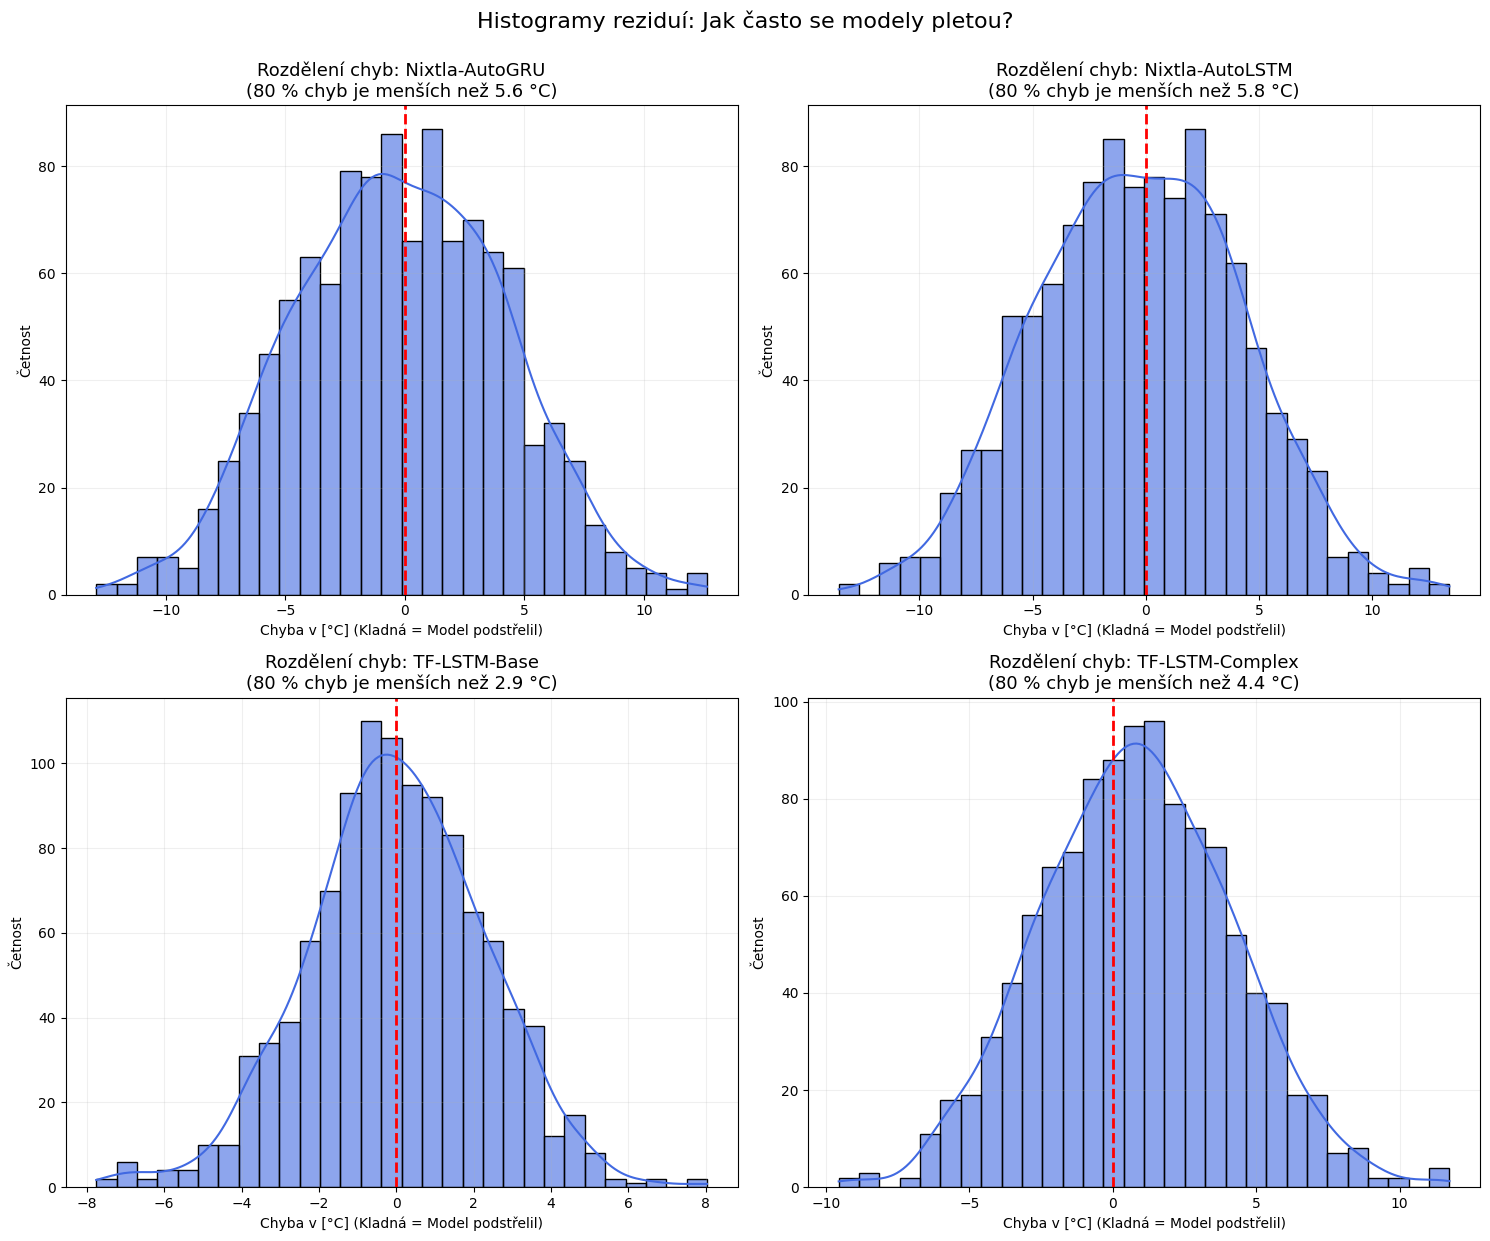

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, res in enumerate(final_results):
    if 'Nixtla' in res['Model']:
        y_actual = forecasts_neural['y'].values
    elif 'Base' in res['Model']:
        y_actual = y_true_b
    else:
        y_actual = y_true_c

    errors = y_actual - res['Predictions']
    abs_errors = np.abs(errors)

    p80 = np.percentile(abs_errors, 80)

    sns.histplot(errors, bins=30, kde=True, ax=axes[i], color='royalblue', alpha=0.6)

    axes[i].axvline(x=0, color='red', linestyle='--', lw=2)
    axes[i].set_title(f"Rozdělení chyb: {res['Model']}\n(80 % chyb je menších než {p80:.1f} °C)", fontsize=13)
    axes[i].set_xlabel("Chyba v [°C] (Kladná = Model podstřelil)")
    axes[i].set_ylabel("Četnost")
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.suptitle("Histogramy reziduí: Jak často se modely pletou?", fontsize=16, y=1.03)
plt.show()